<a href="https://colab.research.google.com/github/LaimengEung/inf-604-data-analysis-i-repo/blob/master/Copy_of_Lab5_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TP5 - EDA: Correlation Analysis**

**Course**: **INF-604: Data Analysis** <br>
**Lecturer**: **Sothea HAS, PhD**

-----

**Objective:** In this lab, you will apply correaltion analysis on real examples. We will also explore the limitations of correaltion analysis and what to watch out when drawing

- You can work directly with `Google Colab` here: [Lab5_EDA.ipynb](https://colab.research.google.com/drive/11JYPdo76e1FPVvm47zDJ5yYI-yzxDuyu?usp=sharing).


-----


In [2]:
%pip install gapminder           # This is for installing the package
from gapminder import gapminder
import pandas as pd
import numpy as np
gapminder.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


# 1. Pearson and Spearman's correlations

**a.** Compute Pearson correlation matrix of the three quantitative variables on year $1952$, $1987$ and then $2007$ using `pd.corr()`. Give a brief intuition of the relationship between these variables.

In [3]:
data1952 = gapminder.query("year == 1952")
data1987 = gapminder.query("year == 1987")
data2007 = gapminder.query("year == 2007")

# 1952
data1952.iloc[:, -3:].corr().style.background_gradient()

,lifeExp,pop,gdpPercap
lifeExp,1.000000,-0.002725,0.278024
pop,-0.002725,1.000000,-0.025260
gdpPercap,0.278024,-0.025260,1.000000


In [7]:
# 1987
data1987.iloc[:, -3:].corr().style.background_gradient()

,lifeExp,pop,gdpPercap
lifeExp,1.000000,0.033062,0.749905
pop,0.033062,1.000000,-0.051705
gdpPercap,0.749905,-0.051705,1.000000


In [8]:
# 2007
data2007.iloc[:, -3:].corr().style.background_gradient()

,lifeExp,pop,gdpPercap
lifeExp,1.000000,0.047553,0.678662
pop,0.047553,1.000000,-0.055676
gdpPercap,0.678662,-0.055676,1.000000


> Description: Back in the past (1952), more GDP doesn't really translate to better helth conditions. Rich country may have low life expectancy, and vice versa. However, this seems to change in coming years, when gdpPercap and lifeExp seems to have high correlation between each other (as shown in the 1987 and 2007 table). <br> <br>
> P.S. After doing spearman's, this is due to outliers only. (Because of one extreme outlier, Kuwait, it **destroys** the information completely) lmaoo... <br>
> However, it is important to not rush to the conclusion, you gotta study (analyse) the Spearman's correlation or log scaled the outlier's column first


,lifeExp,pop,gdpPercap,gdpPercap_scaled
lifeExp,1.000000,-0.002725,0.278024,0.747781
pop,-0.002725,1.000000,-0.025260,-0.107255
gdpPercap,0.278024,-0.025260,1.000000,0.575526
gdpPercap_scaled,0.747781,-0.107255,0.575526,1.000000


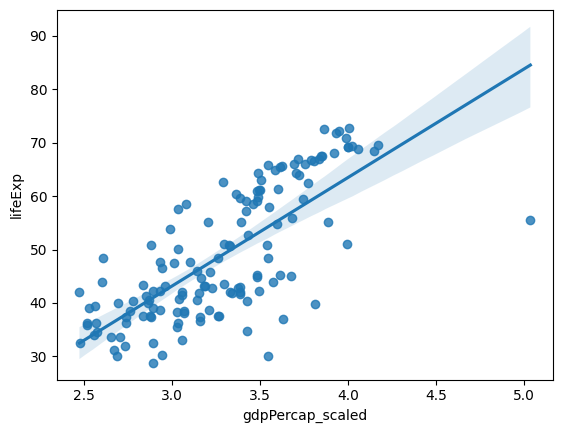

In [9]:
import seaborn as sns
import numpy as np

data1952_log = data1952.copy()
data1952_log['gdpPercap_scaled'] = np.log10(data1952['gdpPercap'])
sns.regplot(data1952_log, x='gdpPercap_scaled', y='lifeExp')

data1952_log.iloc[:, -4:].corr().style.background_gradient()

<Axes: xlabel='gdpPercap', ylabel='lifeExp'>

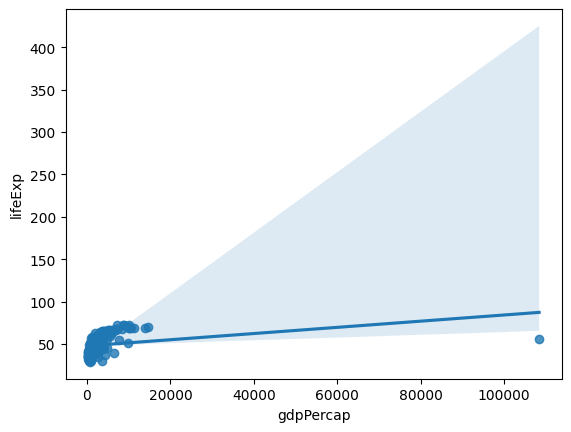

In [10]:
sns.regplot(data1952, x='gdpPercap', y='lifeExp')

**b.** Compute Spearman's Rank Correlation of the previous columns in 1952, 1987 and 2007. What do you observe?

In [11]:
# To do
data1952.iloc[:, -3:].corr(method='spearman').style.background_gradient()

,lifeExp,pop,gdpPercap
lifeExp,1.000000,0.175466,0.768701
pop,0.175466,1.000000,0.086571
gdpPercap,0.768701,0.086571,1.000000


In [12]:
data1987.iloc[:, -3:].corr(method='spearman').style.background_gradient()

,lifeExp,pop,gdpPercap
lifeExp,1.000000,0.053419,0.892465
pop,0.053419,1.000000,0.008355
gdpPercap,0.892465,0.008355,1.000000


In [13]:
data2007.iloc[:, -3:].corr(method='spearman').style.background_gradient()

,lifeExp,pop,gdpPercap
lifeExp,1.000000,0.003355,0.856590
pop,0.003355,1.000000,-0.064588
gdpPercap,0.856590,-0.064588,1.000000


After Computing the Spearman's Rank Correlation of the previous columns, we can see that in **1952**, `gdpPercap` and `lifeExp` does in fact have strong correlation, of **0.77** compared to Pearson's Correlation of just **0.28**.

This clearly shows the flaw of the Pearson Correlation Coefficient due to **extreme outliers**.

**c.** From the previous result, pick the most interesting pair of variables and plot a graphic illustrating their relationship for each year using proper axis scaling and title.

<Axes: xlabel='lifeExp', ylabel='gdpPercap'>

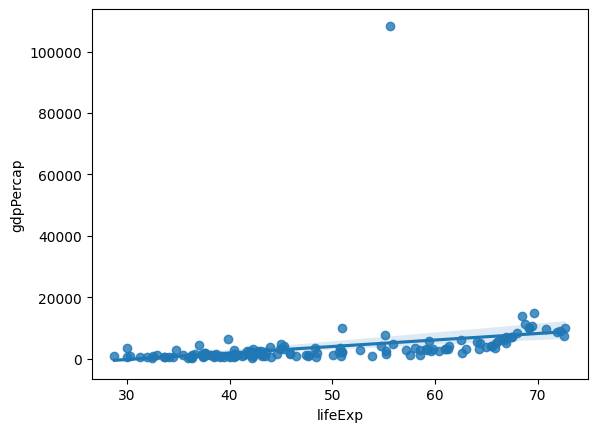

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# To do
sns.regplot(
    data1952,
    x='lifeExp',
    y='gdpPercap'
)

**d.** Revisit your intuition of the correlation matrix in year 1952 from question **(a)**, can you see why we observed such a (poor) correlation in 1952?!

- Now, drop the weird country of year 1952. Revisualize and recompute the correaltion between `health` and `economy` condition of the world in 1952. Conclude.

> **Remark:** Pearson correlation matrix can summarize linear relationship between pairs of quantitative variables but it might be inacurate and influenced by

> - outliers,
> - non-linearity,
> - small sample size,
> - confounding (causal) variables...

# 2. $\eta$-squared correlations

**a.** We have seen how life expectancy and economy vary across continents in 1952 ([Lab4](https://hassothea.github.io/Data_Analysis_AUPP/Labs/Lab4_Data_Visualization.html)) and 2007 ([course](https://hassothea.github.io/Data_Analysis_AUPP/Slides/Data_Visualization.html#/bivariate-visualization-4)).

- Compute $\eta$-squared correlation between `continent` and `lifeExp` then `continent` with `gdpPercap` in 1952, 1987 and 2007 (before and after removing the weird country in 1952).

- Do you find the results reasonable? Explain.

In [ ]:
# To do

# 3. Time evolution

**a.** Draw the evolution of the following correaltions from 1952 to 2007:

- `Person` and `Spearman` corerlation between life expectancy and GDP per capita
- $\eta$-squared coefficients of continent vs life expectancy, and continents vs GDP per capita.

---------

> The following graph is expected.

In [ ]:
# To do


**b.** Fom what you have studied about Gapminder dataset, describe the world from 1952 to 2007.

> Description:

# Further readings
- Gapminder documentation: [https://www.gapminder.org/data/documentation/](https://www.gapminder.org/data/documentation/)
- A short demonstration video is available here: [Hans Rosling's 200 Countries, 200 Years, 4 Minutes - The Joy of Stats - BBC Four](https://youtu.be/jbkSRLYSojo?si=qipg08VIi999hEgo).
- Graphical tools:
    - [`matplotlib`](https://matplotlib.org/stable/index.html)
    - [`seaborn`](https://seaborn.pydata.org/)
    - [`plotly`](https://plotly.com/python/)